# Multilingual MT – Transformer Training (Local)
Chay tren may tinh ca nhan. Du lieu doc tu thu muc du an.

**Chay notebook:** `jupyter notebook notebooks/train_transformer.ipynb`

**Thu muc goc cua du an:** `c:/PKA/Neuron network/Multilingual_MT/`

## Cell 1 – Thiet lap duong dan va thu vien

In [ ]:
import os, sys

# ── Kaggle: khong can mount Drive ────────────────────────────────
# Doi 'multilingual-mt-data' thanh ten dataset ban dat khi upload
DATASET_NAME = 'Multilingual'
DATA_DIR     = f'/kaggle/input/{DATASET_NAME}'
WORK_DIR     = '/kaggle/working'

os.makedirs(f'{WORK_DIR}/model_assets', exist_ok=True)

# Them src/ vao sys.path de import duoc src.*
if DATA_DIR not in sys.path:
    sys.path.insert(0, DATA_DIR)

# Kiem tra file ton tai
checks = {
    'src/models/transformer.py' : f'{DATA_DIR}/src/models/transformer.py',
    'src/data_utils.py'         : f'{DATA_DIR}/src/data_utils.py',
    'tokenizer/tokenizer.json'  : f'{DATA_DIR}/tokenizer/tokenizer.json',
    'data/processed/train.txt'  : f'{DATA_DIR}/data/processed/train.txt',
    'data/processed/val.txt'    : f'{DATA_DIR}/data/processed/val.txt',
}
all_ok = True
for name, path in checks.items():
    ok = os.path.exists(path)
    mb = f'({os.path.getsize(path)/1e6:.1f} MB)' if ok else ''
    print(f'  {"OK  " if ok else "THIEU"} : {name} {mb}')
    if not ok:
        all_ok = False

print()
print('Tat ca file san sang!' if all_ok else 'CANH BAO: Co file bi thieu!')


Project dir : c:\PKA\Neuron network\Multilingual_MT
sys.path[0] : c:\PKA\Neuron network\Multilingual_MT
  OK  : src/models/transformer.py (0.0 MB)
  OK  : src/data_utils.py (0.0 MB)
  OK  : tokenizer/tokenizer.json (1.9 MB)
  OK  : data/processed/train.txt (44.2 MB)
  OK  : data/processed/val.txt (5.2 MB)

Tat ca file san sang!


## Cell 2 – Cau hinh Hyperparameters

In [ ]:
import torch

# ── Cau hinh mo hinh ─────────────────────────────────────────────
VOCAB_SIZE   = 32_000
D_MODEL      = 512
NUM_HEADS    = 8
NUM_LAYERS   = 6
D_FF         = 2048
DROPOUT      = 0.1
PAD_IDX      = 0
BOS_IDX      = 2
EOS_IDX      = 3
MAX_LEN      = 64

# ── Cau hinh huan luyen ───────────────────────────────────────────
NUM_EPOCHS    = 20
BATCH_SIZE    = 64
WARMUP_STEPS  = 4000
LABEL_SMOOTH  = 0.1
GRAD_CLIP     = 1.0
PATIENCE      = 5

# ── Duong dan (Kaggle) ────────────────────────────────────────────
TRAIN_FILE     = f'{DATA_DIR}/data/processed/train.txt'
VAL_FILE       = f'{DATA_DIR}/data/processed/val.txt'
TEST_FILE      = f'{DATA_DIR}/data/processed/test.txt'
TOKENIZER_PATH = f'{DATA_DIR}/tokenizer/tokenizer.json'
BEST_MODEL     = f'{WORK_DIR}/model_assets/best_transformer_model.pt'
CKPT_DIR       = f'{WORK_DIR}/model_assets'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('='*52)
print(f'  d_model={D_MODEL} | heads={NUM_HEADS} | layers={NUM_LAYERS}')
print(f'  batch={BATCH_SIZE} | warmup={WARMUP_STEPS} | device={DEVICE}')
print('='*52)


  CAU HINH THI NGHIEM
  vocab_size   : 32,000
  d_model      : 512  (d_k = 64 / head)
  num_heads    : 8
  num_layers   : 6
  d_ff         : 2048
  dropout      : 0.1
  batch_size   : 32
  warmup_steps : 4000
  label_smooth : 0.1
  device       : cpu


## Cell 3 – Nap DataLoader

In [4]:
from src.data_utils import get_dataloaders

print('Dang nap DataLoader...')
train_loader, val_loader, test_loader = get_dataloaders(
    train_file     = TRAIN_FILE,
    val_file       = VAL_FILE,
    test_file      = TEST_FILE,
    tokenizer_path = TOKENIZER_PATH,
    max_len        = MAX_LEN,
    batch_size     = BATCH_SIZE,
    num_workers    = 0,   # Windows: de 0 tranh loi multiprocessing
)

batch = next(iter(train_loader))
print(f'Batch src : {tuple(batch["src"].shape)}  # [B={BATCH_SIZE}, T={MAX_LEN}]')
print(f'Batch tgt : {tuple(batch["tgt"].shape)}')
print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')

[23:32:07] INFO     Khoi tao DataLoader (batch_size=32, max_len=64) ...


Dang nap DataLoader...


[23:32:07] INFO     Nap tokenizer: c:\PKA\Neuron network\Multilingual_MT\tokenizer\tokenizer.json (vocab=32000)
[23:32:08] INFO     Dataset 'train.txt': 255000 mau hop le, bo qua 0 dong.
[23:32:08] INFO     Nap tokenizer: c:\PKA\Neuron network\Multilingual_MT\tokenizer\tokenizer.json (vocab=32000)
[23:32:09] INFO     Dataset 'val.txt': 30000 mau hop le, bo qua 0 dong.
[23:32:09] INFO     Nap tokenizer: c:\PKA\Neuron network\Multilingual_MT\tokenizer\tokenizer.json (vocab=32000)
[23:32:09] INFO     Dataset 'test.txt': 15000 mau hop le, bo qua 0 dong.
[23:32:09] INFO     Hoan tat:
  Train : 255000 mau | 7969 batch
  Val   :  30000 mau |  938 batch
  Test  :  15000 mau |  469 batch


Batch src : (32, 64)  # [B=32, T=64]
Batch tgt : (32, 64)
Train batches : 7969
Val   batches : 938


## Cell 4 – Khoi tao mo hinh Transformer

In [5]:
from src.models.transformer import Transformer

model = Transformer(
    vocab_size = VOCAB_SIZE,
    d_model    = D_MODEL,
    num_heads  = NUM_HEADS,
    num_layers = NUM_LAYERS,
    d_ff       = D_FF,
    dropout    = DROPOUT,
    pad_idx    = PAD_IDX,
    max_len    = MAX_LEN + 10,
).to(DEVICE)

total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Tong tham so: {total:,}')

# Smoke test
with torch.no_grad():
    _s = torch.randint(1, VOCAB_SIZE, (2, MAX_LEN)).to(DEVICE)
    _t = torch.randint(1, VOCAB_SIZE, (2, MAX_LEN)).to(DEVICE)
    _o = model(_s, _t)
    print(f'Smoke test logits: {tuple(_o.shape)}  # [B, T-1, V]')

Tong tham so: 76,871,680
Smoke test logits: (2, 63, 32000)  # [B, T-1, V]


## Cell 5 – Noam Scheduler
```
lr(step) = D^(-0.5) * min(step^(-0.5), step * warmup^(-1.5))
```
- Giai doan warmup: lr tang tuyen tinh den dinh tai step=warmup_steps
- Giai doan decay : lr giam ty le nghich voi sqrt(step)

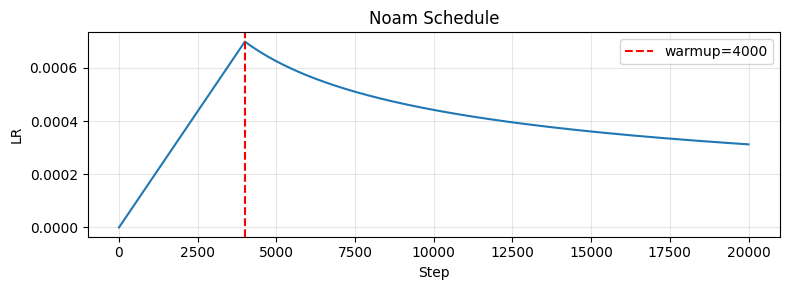

LR dinh (step=4000): 0.000699


In [6]:
import torch.nn as nn
import matplotlib.pyplot as plt

class NoamScheduler:
    """Ghi lr truc tiep vao optimizer, dung cong thuc Noam chuan xac."""
    def __init__(self, optimizer, d_model: int, warmup_steps: int):
        self.optimizer    = optimizer
        self.d_model      = d_model
        self.warmup_steps = warmup_steps
        self.step_num     = 0

    def step(self):
        self.step_num += 1
        lr = (self.d_model ** -0.5) * min(
            self.step_num ** -0.5,
            self.step_num * (self.warmup_steps ** -1.5),
        )
        for pg in self.optimizer.param_groups:
            pg['lr'] = lr

    def get_lr(self) -> float:
        return self.optimizer.param_groups[0]['lr']


optimizer = torch.optim.Adam(
    model.parameters(), lr=1.0,
    betas=(0.9, 0.98), eps=1e-9,
)
scheduler = NoamScheduler(optimizer, D_MODEL, WARMUP_STEPS)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX, label_smoothing=LABEL_SMOOTH)

# Ve duong cong lr
steps = list(range(1, 20001))
lrs   = [(D_MODEL**-0.5)*min(s**-0.5, s*WARMUP_STEPS**-1.5) for s in steps]
plt.figure(figsize=(8, 3))
plt.plot(steps, lrs)
plt.axvline(WARMUP_STEPS, color='red', linestyle='--', label=f'warmup={WARMUP_STEPS}')
plt.xlabel('Step'); plt.ylabel('LR'); plt.title('Noam Schedule')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print(f'LR dinh (step={WARMUP_STEPS}): {lrs[WARMUP_STEPS-1]:.6f}')

## Cell 6 – Training Loop (co tien trinh)

In [7]:
import time, os
import torch.nn as nn
from tqdm import tqdm   # dung tqdm thuong (khong phai notebook)

# ── Ham chay 1 epoch ─────────────────────────────────────────────
def run_epoch(model, loader, criterion, optimizer, scheduler, device, is_train):
    model.train() if is_train else model.eval()
    total_loss = 0.0
    n = 0
    ctx = torch.enable_grad() if is_train else torch.no_grad()

    label = "TRAIN" if is_train else "VAL  "
    pbar  = tqdm(loader, desc=f"  {label}", ncols=90, leave=False)

    with ctx:
        for batch in pbar:
            src = batch["src"].to(device)
            tgt = batch["tgt"].to(device)

            logits       = model(src, tgt)        # [B, T-1, V]
            B, T1, V     = logits.shape
            loss         = criterion(logits.reshape(B * T1, V),
                                     tgt[:, 1:].reshape(B * T1))
            total_loss  += loss.item()
            n           += 1

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
                scheduler.step()
                pbar.set_postfix(
                    loss=f"{total_loss/n:.4f}",
                    lr=f"{scheduler.get_lr():.2e}"
                )
            else:
                pbar.set_postfix(loss=f"{total_loss/n:.4f}")

    return total_loss / n if n else float("inf")


# ── Ham luu checkpoint ────────────────────────────────────────────
def save_checkpoint(model, optimizer, scheduler, epoch, val_loss, path):
    torch.save({
        "epoch"       : epoch,
        "step_num"    : scheduler.step_num,
        "model_state" : model.state_dict(),
        "optim_state" : optimizer.state_dict(),
        "val_loss"    : val_loss,
        "model_config": model.config,
    }, path)


# ── Vong lap chinh ────────────────────────────────────────────────
best_val    = float("inf")
no_improve  = 0
history     = []

print("=" * 62)
print(f"  TRANSFORMER  |  {NUM_EPOCHS} epochs  |  {DEVICE}")
print(f"  d={D_MODEL}  H={NUM_HEADS}  N={NUM_LAYERS}  warmup={WARMUP_STEPS}")
print("=" * 62)

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    print(f"\nEpoch [{epoch:02d}/{NUM_EPOCHS}]")

    tr_loss = run_epoch(model, train_loader, criterion,
                        optimizer, scheduler, DEVICE, is_train=True)
    vl_loss = run_epoch(model, val_loader, criterion,
                        optimizer, scheduler, DEVICE, is_train=False)

    elapsed = time.time() - t0
    cur_lr  = scheduler.get_lr()
    improved = vl_loss < best_val

    history.append({
        "epoch": epoch, "train": tr_loss,
        "val"  : vl_loss, "lr"  : cur_lr
    })

    # In ket qua epoch
    print(f"  Train Loss : {tr_loss:.4f}")
    print(f"  Val   Loss : {vl_loss:.4f}{'  <-- BEST' if improved else ''}")
    print(f"  LR         : {cur_lr:.4e}")
    print(f"  Time       : {elapsed:.0f}s  ({elapsed/60:.1f} min)")

    # Luu checkpoint
    ckpt_path = os.path.join(CKPT_DIR, f"transformer_ep{epoch:02d}.pt")
    save_checkpoint(model, optimizer, scheduler, epoch, vl_loss, ckpt_path)

    if improved:
        best_val   = vl_loss
        no_improve = 0
        save_checkpoint(model, optimizer, scheduler, epoch, vl_loss, BEST_MODEL)
        print(f"  -> Luu best model: {BEST_MODEL}")
    else:
        no_improve += 1
        print(f"  Patience   : {no_improve}/{PATIENCE}")
        if no_improve >= PATIENCE:
            print(f"\nEarly stopping tai epoch {epoch}.")
            break

print("\n" + "=" * 62)
print(f"XONG!  Best Val Loss = {best_val:.4f}")
print(f"Model : {BEST_MODEL}")


  TRANSFORMER  |  20 epochs  |  cpu
  d=512  H=8  N=6  warmup=4000

Epoch [01/20]


KeyboardInterrupt: 

## Cell 7 – Do thi Loss Curve

In [ ]:
import matplotlib.pyplot as plt

eps    = [h['epoch'] for h in history]
trains = [h['train'] for h in history]
vals   = [h['val']   for h in history]
lrs    = [h['lr']    for h in history]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax1 = axes[0]
ax1.plot(eps, trains, 'b-o', markersize=4, label='Train Loss')
ax1.plot(eps, vals,   'r-o', markersize=4, label='Val Loss')
ax1.axhline(y=4.25, color='gray', linestyle='--', alpha=0.6,
            label='LSTM Baseline Val ~4.25')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Training & Validation Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2 = axes[1]
ax2.plot(eps, lrs, 'g-o', markersize=4)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('LR')
ax2.set_title('Learning Rate (Noam – cuoi moi epoch)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
save_path = os.path.join(CKPT_DIR, 'loss_curve_transformer.png')
plt.savefig(save_path, dpi=150)
plt.show()
print(f'Da luu bieu do: {save_path}')

print(f'\n{"Epoch":>5} | {"Train":>8} | {"Val":>8} | {"LR":>10}')
print('-'*42)
best_e = min(history, key=lambda x: x['val'])
for h in history:
    mark = ' *' if h['epoch'] == best_e['epoch'] else ''
    print(f'{h["epoch"]:>5} | {h["train"]:>8.4f} | {h["val"]:>8.4f} | {h["lr"]:>10.2e}{mark}')

## Cell 8 – Resume tu Checkpoint (neu bi ngat)

In [ ]:
# Chay cell nay neu qua trinh train bi ngat, sau do chay lai Cell 6
RESUME_PATH = BEST_MODEL   # hoac chi dinh file cu the

if os.path.exists(RESUME_PATH):
    ckpt = torch.load(RESUME_PATH, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state'])
    optimizer.load_state_dict(ckpt['optim_state'])
    scheduler.step_num = ckpt['step_num']
    START_EPOCH   = ckpt['epoch'] + 1
    best_val_loss = ckpt['val_loss']
    print(f'Resume tu epoch {ckpt["epoch"]} | Val: {ckpt["val_loss"]:.4f}')
    print(f'Scheduler step: {scheduler.step_num}')
    print(f'Tiep tuc tu epoch {START_EPOCH} ...')
    print('(Doi dong range trong Cell 6 thanh: range(START_EPOCH, NUM_EPOCHS+1))')
else:
    print('Khong tim thay checkpoint. Bat dau tu epoch 1.')

## Cell 9 – Thu dich cau mau

In [ ]:
from tokenizers import Tokenizer as HFTok

tok = HFTok.from_file(TOKENIZER_PATH)

def translate(src_text: str, max_out: int = MAX_LEN) -> str:
    model.eval()
    ids  = tok.encode(src_text).ids[:MAX_LEN]
    ids += [PAD_IDX] * (MAX_LEN - len(ids))
    src_t   = torch.tensor([ids], dtype=torch.long).to(DEVICE)
    out_ids = model.translate_greedy(src_t, BOS_IDX, EOS_IDX, max_out)
    return tok.decode(out_ids, skip_special_tokens=True)

tests = [
    '<2vi> Hello , how are you ?',
    '<2vi> I love machine learning .',
    '<2ja> The weather is beautiful today .',
    '<2zh> Thank you very much .',
]

print('Thu dich sau khi train:\n')
for s in tests:
    print(f'  SRC : {s}')
    print(f'  OUT : {translate(s)}')
    print()